In [1]:
%reset -f
import numpy as np
from samplers.SEIR_emcee import SEIR_emcee
from samplers.SEIR_pytwalk import SEIR_pytwalk
from samplers.SEIR_pyhmc import SEIR_pyhmc
from epidemic_model import SEIR_Model
from utils.utils import load_data, parser
import sys
import matplotlib.pyplot as plt
from time import time
from joblib import dump, load

In [2]:
from bokeh.io import output_notebook, show

output_notebook()

Loading BokehJS ...

Data loaded from file:  data/Smoothed_Cases_Third_Wave.csv


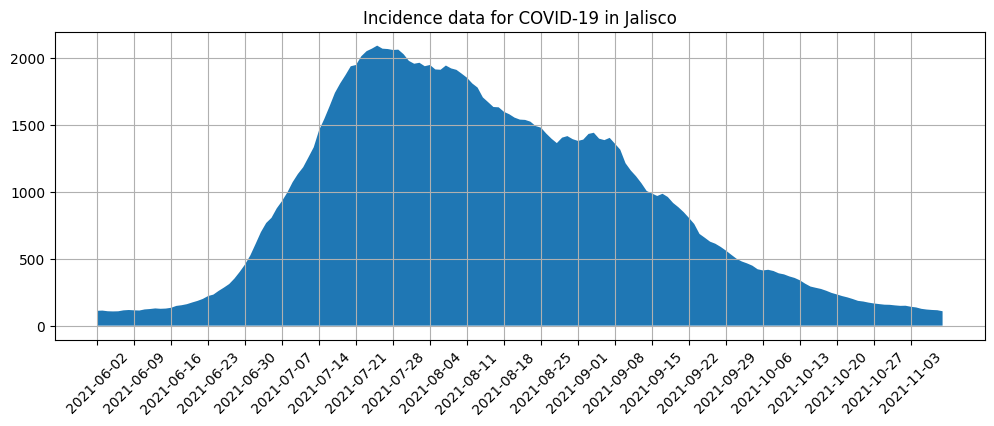

In [3]:
# Loading configuration from configuration file
fname_conf = './configuration_file_test.cfg'

params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [4]:
print(dates[0], dates[-1])
print(np.sum(data))

2021-06-02 2021-11-09
144769.7142857143


In [5]:
# Total population size is taken from the configuration file
N = params["N"]

# Setting initial conditions
E0 = data[0]*5 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

iterations = params['iterations']  # Number of iterations for the MCMC sampler
ndim = 3                           # Dimension of the problem is 3: beta, sigma, gamma

reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']

In [6]:
#### Run this cell in case that are loading a previous run
if reload_flag :
    seir_pyhmc = load(outpath+'/pyhmc/'+out_file)
    seir_pyhmc.outpath = outpath

In [7]:
if not reload_flag :
        seir_pyhmc = SEIR_pyhmc(
                ndim=ndim,
                data=data,
                time=times,
                x0=x0,
                labels=['beta', 'sigma', 'gamma'],
                **params
                )
        
        p0 = np.array([0.35,0.05,0.2])


In [8]:
if not reload_flag :
    ini_time = time()
    seir_pyhmc.run(iterations,p0)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)

    dump(seir_pyhmc, outpath+'/pyhmc/'+out_file)

  0%|          | 2/15000 [00:00<12:37, 19.81it/s]

[0.34997389 0.05005897 0.11499087] -3.852718739461994 0 0


  0%|          | 57/15000 [00:01<05:48, 42.91it/s]

[0.34941207 0.05016704 0.00129113] -4.230979688815145 0 0


  1%|          | 107/15000 [00:02<06:37, 37.47it/s]

[0.35004982 0.05004488 0.01344515] -4.264600645799773 0 0


  1%|          | 157/15000 [00:04<06:34, 37.65it/s]

[0.3499753  0.0498892  0.01160093] -4.261290559918638 0 0


  1%|▏         | 209/15000 [00:05<05:53, 41.80it/s]

[0.35010241 0.0503332  0.00309909] -4.233979200297729 0 0


  2%|▏         | 255/15000 [00:06<06:37, 37.12it/s]

[0.34897649 0.05091165 0.00630731] -4.239224765500415 0 0


  2%|▏         | 305/15000 [00:07<06:23, 38.32it/s]

[0.34842179 0.05062039 0.00948154] -4.251155512248514 0 0


  2%|▏         | 355/15000 [00:09<06:31, 37.39it/s]

[0.34721671 0.05154329 0.0106376 ] -4.247960323940655 0 0


  3%|▎         | 407/15000 [00:10<06:33, 37.10it/s]

[0.34668473 0.05157804 0.01368663] -4.2567235416503335 0 0


  3%|▎         | 455/15000 [00:11<06:44, 35.94it/s]

[0.34638069 0.05170094 0.01109312] -4.2488612881009855 0 0


  3%|▎         | 508/15000 [00:13<06:22, 37.90it/s]

[0.34610007 0.05131525 0.00623814] -4.238329757188542 0 0


  4%|▎         | 556/15000 [00:14<05:25, 44.35it/s]

[0.34618437 0.05087748 0.00184329] -4.2295381780604995 0 0


  4%|▍         | 605/15000 [00:15<05:55, 40.52it/s]

[3.46873333e-01 5.08783448e-02 1.00000000e-06] -4.223140945861049 0 0


  4%|▍         | 658/15000 [00:17<06:26, 37.07it/s]

[0.34672995 0.05101429 0.01284565] -4.25869548628291 0 0


  5%|▍         | 706/15000 [00:18<05:50, 40.74it/s]

[0.34715841 0.05126014 0.00822532] -4.243614889295675 0 0


  5%|▌         | 757/15000 [00:19<06:53, 34.45it/s]

[0.34740146 0.0512195  0.11500522] -3.859887741623766 0 0


  5%|▌         | 808/15000 [00:21<05:50, 40.53it/s]

[0.34712634 0.0514551  0.00355002] -4.228123788170302 1 0


  6%|▌         | 858/15000 [00:22<05:07, 45.93it/s]

[3.47193086e-01 5.19032232e-02 1.00000000e-06] -4.21276518835251 1 0


  6%|▌         | 906/15000 [00:23<05:36, 41.89it/s]

[0.34771485 0.05210587 0.00051109] -4.211843347086196 1 0


  6%|▋         | 957/15000 [00:24<05:44, 40.74it/s]

[0.34763994 0.0522484  0.00669605] -4.229945480829427 1 0


  7%|▋         | 1002/15000 [00:26<06:17, 37.06it/s]

[0.34758248 0.05217469 0.06088444] -4.305747837626575 1 0


  7%|▋         | 1062/15000 [00:27<05:04, 45.76it/s]

[0.34761828 0.05233246 0.00361278] -4.219747041833383 2 0


  7%|▋         | 1105/15000 [00:28<06:14, 37.09it/s]

[0.34785581 0.05205097 0.00988393] -4.240885924454557 2 0


  8%|▊         | 1157/15000 [00:30<06:01, 38.26it/s]

[0.34867877 0.05093768 0.00600334] -4.238355827335123 2 0


  8%|▊         | 1207/15000 [00:31<04:41, 48.92it/s]

[3.47942580e-01 5.15918373e-02 1.00000000e-06] -4.21507377956739 2 0


  8%|▊         | 1256/15000 [00:32<06:09, 37.24it/s]

[0.34797104 0.05144023 0.00965437] -4.24521716719134 2 0


  9%|▊         | 1305/15000 [00:33<06:08, 37.16it/s]

[0.3482265  0.05127256 0.02476566] -4.285161380214534 2 0


  9%|▉         | 1357/15000 [00:35<06:07, 37.14it/s]

[0.34713134 0.05183299 0.01118933] -4.247316800822199 2 0


  9%|▉         | 1406/15000 [00:36<06:04, 37.26it/s]

[0.34618548 0.05219679 0.0048003 ] -4.225912278783348 2 0


 10%|▉         | 1458/15000 [00:37<06:04, 37.19it/s]

[0.3475206  0.05217671 0.01203819] -4.24636392265761 2 0


 10%|█         | 1505/15000 [00:39<05:55, 37.99it/s]

[0.34446055 0.05627367 0.00766793] -4.19829552615989 2 0


 10%|█         | 1555/15000 [00:40<04:55, 45.55it/s]

[3.43971761e-01 5.63038133e-02 1.00000000e-06] -4.17119741074607 2 0


 11%|█         | 1607/15000 [00:41<05:59, 37.21it/s]

[0.34403603 0.05624794 0.01006916] -4.2076213842538195 2 0


 11%|█         | 1654/15000 [00:43<05:25, 41.03it/s]

[0.34405226 0.05608961 0.01008376] -4.2090005786538205 2 0


 11%|█▏        | 1708/15000 [00:44<05:57, 37.16it/s]

[0.3439864  0.05590552 0.01034027] -4.211599557213853 2 0


 12%|█▏        | 1757/15000 [00:45<05:40, 38.94it/s]

[0.34356226 0.05562547 0.00500986] -4.196564141832161 2 0


 12%|█▏        | 1805/15000 [00:46<05:48, 37.82it/s]

[0.34341989 0.05565587 0.01204373] -4.22046731088895 2 0


 12%|█▏        | 1857/15000 [00:48<05:57, 36.80it/s]

[0.34363133 0.05598276 0.00867425] -4.205825220481973 2 0


 13%|█▎        | 1908/15000 [00:49<05:47, 37.62it/s]

[0.34346363 0.05640897 0.02262911] -4.248236969331686 2 0


 13%|█▎        | 1955/15000 [00:50<05:49, 37.37it/s]

[0.34300214 0.05617938 0.00932835] -4.206842988158265 2 0


 13%|█▎        | 2007/15000 [00:52<05:52, 36.85it/s]

[0.3435296  0.05593553 0.00979876] -4.210142298534002 2 0


 14%|█▎        | 2056/15000 [00:53<05:45, 37.46it/s]

[0.34348404 0.05531823 0.00631365] -4.204316121432845 2 0


 14%|█▍        | 2108/15000 [00:54<05:46, 37.15it/s]

[0.34510345 0.05380055 0.01011754] -4.229134222615542 2 0


 14%|█▍        | 2158/15000 [00:56<05:14, 40.88it/s]

[0.34586247 0.05333968 0.0078146 ] -4.2253302062867535 2 0


 15%|█▍        | 2206/15000 [00:57<05:41, 37.50it/s]

[0.34600461 0.05331518 0.00908265] -4.229383147463047 2 0


 15%|█▌        | 2255/15000 [00:58<05:14, 40.50it/s]

[0.34607693 0.05277782 0.00337748] -4.21643647131886 2 0


 15%|█▌        | 2308/15000 [01:00<05:42, 37.11it/s]

[0.3459087  0.05261    0.00995276] -4.238222007055557 2 0


 16%|█▌        | 2357/15000 [01:01<05:13, 40.31it/s]

[0.34615118 0.05300677 0.0074329 ] -4.226881879112113 2 0


 16%|█▌        | 2406/15000 [01:02<05:40, 37.03it/s]

[0.3459325  0.05330926 0.01057591] -4.234047885987413 2 0


 16%|█▋        | 2458/15000 [01:04<05:37, 37.17it/s]

[0.34625128 0.05322599 0.01061342] -4.23460084855531 2 0


 17%|█▋        | 2508/15000 [01:05<05:05, 40.89it/s]

[0.34647231 0.05338597 0.0096087 ] -4.229839479238996 2 0


 17%|█▋        | 2558/15000 [01:06<05:31, 37.53it/s]

[0.34648966 0.05322751 0.00994627] -4.232219558682097 2 0


 17%|█▋        | 2606/15000 [01:07<05:36, 36.78it/s]

[0.34603938 0.05338409 0.01308396] -4.240929933021284 2 0


 18%|█▊        | 2658/15000 [01:09<05:29, 37.43it/s]

[0.3463364  0.05220225 0.00680212] -4.231988446268925 2 0


 18%|█▊        | 2707/15000 [01:10<05:23, 38.04it/s]

[0.34667895 0.05137159 0.00676729] -4.23875446664134 2 0


 18%|█▊        | 2755/15000 [01:11<05:27, 37.43it/s]

[0.34742978 0.05114827 0.01256644] -4.256450567019626 2 0


 19%|█▊        | 2807/15000 [01:13<05:25, 37.46it/s]

[0.34775543 0.05143987 0.01608434] -4.26322971012679 2 0


 19%|█▉        | 2855/15000 [01:14<05:22, 37.64it/s]

[0.34748485 0.05143731 0.00978304] -4.24626725389923 2 0


 19%|█▉        | 2906/15000 [01:15<05:21, 37.63it/s]

[0.34723005 0.05141734 0.01285222] -4.255128025130577 2 0


 20%|█▉        | 2958/15000 [01:17<04:26, 45.14it/s]

[0.34741118 0.05164352 0.00311431] -4.224856632227678 2 0


 20%|██        | 3008/15000 [01:18<05:12, 38.36it/s]

[0.34821811 0.0506331  0.01085056] -4.255010117814475 2 0


 20%|██        | 3052/15000 [01:19<05:52, 33.87it/s]

[0.34877853 0.05050497 0.27505719] -0.958439611268362 2 0


 21%|██        | 3107/15000 [01:21<05:23, 36.78it/s]

[0.34908918 0.05072405 0.00846404] -4.246805165045827 3 0


 21%|██        | 3160/15000 [01:22<03:46, 52.27it/s]

[0.34841505 0.05065376 0.00177545] -4.228922992918024 3 0


 21%|██▏       | 3206/15000 [01:23<04:53, 40.13it/s]

[0.34846351 0.05042815 0.0087606 ] -4.25072897644659 3 0


 22%|██▏       | 3257/15000 [01:24<04:45, 41.18it/s]

[0.34850141 0.05049386 0.00512016] -4.240014140149845 3 0


 22%|██▏       | 3309/15000 [01:26<04:32, 42.86it/s]

[0.34905616 0.05030492 0.00683886] -4.245964540799906 3 0


 22%|██▏       | 3358/15000 [01:27<04:34, 42.40it/s]

[0.34872597 0.050506   0.00552055] -4.240698978878938 3 0


 23%|██▎       | 3405/15000 [01:28<05:09, 37.42it/s]

[0.34884137 0.05028222 0.01424082] -4.265925034001279 3 0


 23%|██▎       | 3457/15000 [01:30<05:10, 37.21it/s]

[0.34876621 0.05060386 0.01234487] -4.25882119188993 3 0


 23%|██▎       | 3505/15000 [01:31<05:06, 37.53it/s]

[0.34880077 0.05043877 0.01187273] -4.2585677035814244 3 0


 24%|██▎       | 3557/15000 [01:32<04:02, 47.21it/s]

[3.48723229e-01 5.01448987e-02 1.00000000e-06] -4.22808406316967 3 0


 24%|██▍       | 3608/15000 [01:33<03:52, 48.96it/s]

[0.34880303 0.0506273  0.00143478] -4.2279161028919985 3 0


 24%|██▍       | 3658/15000 [01:34<04:46, 39.57it/s]

[0.34857105 0.05063166 0.00629917] -4.242063404352969 3 0


 25%|██▍       | 3706/15000 [01:36<05:01, 37.47it/s]

[0.34794099 0.05032289 0.01096044] -4.257859761125922 3 0


 25%|██▌       | 3756/15000 [01:37<04:25, 42.32it/s]

[0.34787831 0.0499228  0.00303022] -4.239639109157703 3 0


 25%|██▌       | 3807/15000 [01:38<04:57, 37.62it/s]

[0.34797404 0.05003923 0.00508806] -4.244283745230414 3 0


 26%|██▌       | 3855/15000 [01:40<04:56, 37.65it/s]

[0.34706251 0.0496946  0.02338958] -4.291908812056186 3 0


 26%|██▌       | 3907/15000 [01:41<04:56, 37.47it/s]

[0.3461886  0.04942343 0.01153752] -4.267605178639376 3 0


 26%|██▋       | 3955/15000 [01:42<04:55, 37.41it/s]

[0.34606547 0.04928125 0.01682248] -4.281004575643334 3 0


 27%|██▋       | 4007/15000 [01:44<04:52, 37.62it/s]

[0.3460103  0.04937994 0.01081014] -4.266405145103294 3 0


 27%|██▋       | 4055/15000 [01:45<04:54, 37.22it/s]

[0.34606049 0.04922635 0.01590111] -4.279352830637204 3 0


 27%|██▋       | 4107/15000 [01:46<04:50, 37.50it/s]

[0.34650171 0.04926741 0.0127886 ] -4.271350047146156 3 0


 28%|██▊       | 4157/15000 [01:48<04:44, 38.13it/s]

[0.34736012 0.04917661 0.01314723] -4.272244313981512 3 0


 28%|██▊       | 4207/15000 [01:49<04:44, 37.88it/s]

[0.34792284 0.04897373 0.01162588] -4.269625347520219 3 0


 28%|██▊       | 4255/15000 [01:50<04:48, 37.29it/s]

[0.34752596 0.04884796 0.00964279] -4.265909060932359 3 0


 29%|██▊       | 4304/15000 [01:51<04:27, 39.92it/s]

[0.34738628 0.0486807  0.00939257] -4.266692589404344 3 0


 29%|██▉       | 4357/15000 [01:53<04:58, 35.64it/s]

[0.34857605 0.04854467 0.00839311] -4.264367088357267 4 0


 29%|██▉       | 4405/15000 [01:54<04:42, 37.48it/s]

[0.34836409 0.04861072 0.00382794] -4.252594511924329 4 0


 30%|██▉       | 4459/15000 [01:56<04:19, 40.68it/s]

[0.34858167 0.04843649 0.00651285] -4.260519251873152 4 0


 30%|███       | 4510/15000 [01:57<04:11, 41.79it/s]

[0.34886564 0.04828537 0.00581914] -4.259671252984091 4 0


 30%|███       | 4557/15000 [01:58<04:50, 35.97it/s]

[0.34864581 0.04835905 0.03229678] -4.3102465142040165 4 0


 31%|███       | 4604/15000 [02:00<07:15, 23.86it/s]

[0.348795   0.0485496  0.09583101] -4.059230030692972 7 0


 31%|███       | 4656/15000 [02:01<04:36, 37.39it/s]

[0.34894147 0.04835401 0.07094138] -4.253045574556576 8 0


 31%|███▏      | 4708/15000 [02:03<04:36, 37.26it/s]

[0.34685081 0.04829213 0.0146163 ] -4.281522830159547 8 0


 32%|███▏      | 4756/15000 [02:04<03:43, 45.81it/s]

[3.45781878e-01 4.83344454e-02 1.00000000e-06] -4.246917472644251 8 0


 32%|███▏      | 4808/15000 [02:05<04:09, 40.77it/s]

[3.45971602e-01 4.82763247e-02 1.00000000e-06] -4.247288559882133 8 0


 32%|███▏      | 4858/15000 [02:07<04:25, 38.22it/s]

[0.34591037 0.04807643 0.01104454] -4.275876987904367 8 0


 33%|███▎      | 4907/15000 [02:08<04:26, 37.84it/s]

[0.34559428 0.04819819 0.00872937] -4.270095927540457 8 0


 33%|███▎      | 4955/15000 [02:09<04:02, 41.46it/s]

[0.34512286 0.04805651 0.00248616] -4.256380431372674 8 0


 33%|███▎      | 5006/15000 [02:10<03:55, 42.42it/s]

[0.3443317  0.04821176 0.0039935 ] -4.259494641401284 8 0


 34%|███▎      | 5056/15000 [02:12<04:23, 37.70it/s]

[0.34406754 0.04805589 0.01109652] -4.2774941070803205 8 0


 34%|███▍      | 5105/15000 [02:13<04:23, 37.51it/s]

[0.34465484 0.04803888 0.01203173] -4.279277258041951 8 0


 34%|███▍      | 5157/15000 [02:14<04:25, 37.13it/s]

[0.34508283 0.04780029 0.01032018] -4.276751344480986 8 0


 35%|███▍      | 5209/15000 [02:15<03:46, 43.24it/s]

[0.34466923 0.04782149 0.00460027] -4.263609805489392 8 0


 35%|███▌      | 5256/15000 [02:17<04:18, 37.68it/s]

[0.3444173  0.04796014 0.01014015] -4.2756845972813595 8 0


 35%|███▌      | 5305/15000 [02:18<04:12, 38.45it/s]

[0.34428966 0.04844595 0.00237532] -4.253721429087163 8 0


 36%|███▌      | 5357/15000 [02:19<04:17, 37.39it/s]

[0.34254169 0.04846466 0.01031362] -4.2742938897764375 8 0


 36%|███▌      | 5405/15000 [02:21<04:17, 37.29it/s]

[0.3421218  0.04862434 0.0097216 ] -4.272287240544104 8 0


 36%|███▋      | 5458/15000 [02:22<03:53, 40.80it/s]

[0.34230181 0.04894654 0.0083369 ] -4.266392503391463 8 0


 37%|███▋      | 5507/15000 [02:23<04:13, 37.41it/s]

[0.34257344 0.04897233 0.01624205] -4.284175573719283 8 0


 37%|███▋      | 5556/15000 [02:24<03:11, 49.33it/s]

[3.42374754e-01 5.00650080e-02 1.00000000e-06] -4.23515170333629 8 0


 37%|███▋      | 5608/15000 [02:26<03:45, 41.61it/s]

[0.34253811 0.05017767 0.00942859] -4.259899692524383 8 0


 38%|███▊      | 5658/15000 [02:27<04:08, 37.55it/s]

[0.34252198 0.05020196 0.01869334] -4.282256806685533 8 0


 38%|███▊      | 5706/15000 [02:28<04:08, 37.41it/s]

[0.34282238 0.04999742 0.03441094] -4.3105339493102575 8 0


 38%|███▊      | 5758/15000 [02:29<03:56, 39.06it/s]

[0.36104053 0.03356458 0.01044087] -4.280360244172089 8 0


 39%|███▊      | 5809/15000 [02:31<03:26, 44.54it/s]

[0.36084626 0.03345506 0.00053018] -4.28358178425766 8 0


 39%|███▉      | 5855/15000 [02:32<03:51, 39.48it/s]

[0.36151417 0.03324938 0.01080746] -4.27751806467014 8 0


 39%|███▉      | 5906/15000 [02:33<03:47, 39.91it/s]

[0.36166234 0.03308319 0.00811976] -4.2779537183777565 8 0


 40%|███▉      | 5959/15000 [02:34<02:50, 52.99it/s]

[3.62302256e-01 3.29543172e-02 1.00000000e-06] -4.28033522297564 8 0


 40%|████      | 6004/15000 [02:35<03:18, 45.37it/s]

[0.36251582 0.03297247 0.0029882 ] -4.279888414090402 8 0


 40%|████      | 6058/15000 [02:37<03:52, 38.39it/s]

[0.36261631 0.03294831 0.00951439] -4.275941911468015 8 0


 41%|████      | 6106/15000 [02:38<03:30, 42.21it/s]

[0.36244647 0.03305213 0.00323   ] -4.280377217748982 8 0


 41%|████      | 6157/15000 [02:39<03:09, 46.57it/s]

[0.36257243 0.03281088 0.00377079] -4.27833392512757 8 0


 41%|████▏     | 6205/15000 [02:40<03:48, 38.55it/s]

[0.36223238 0.03257868 0.01002523] -4.271966325497436 8 0


 42%|████▏     | 6257/15000 [02:41<03:56, 37.01it/s]

[0.36237569 0.03280528 0.03292489] -4.231669640340944 8 0


 42%|████▏     | 6304/15000 [02:43<03:16, 44.21it/s]

[0.36192714 0.0329813  0.00823104] -4.277112723670265 8 0


 42%|████▏     | 6355/15000 [02:44<03:53, 37.05it/s]

[0.36236547 0.03251333 0.01572178] -4.2646864843429535 8 0


 43%|████▎     | 6407/15000 [02:45<03:53, 36.78it/s]

[0.36275414 0.0327175  0.02909159] -4.241612468990408 8 0


 43%|████▎     | 6455/15000 [02:47<03:51, 36.89it/s]

[0.36409703 0.03265597 0.01567122] -4.267020273352398 8 0


 43%|████▎     | 6508/15000 [02:48<03:50, 36.82it/s]

[0.36421741 0.03265538 0.0094224 ] -4.273818133351838 8 0


 44%|████▎     | 6561/15000 [02:49<02:55, 48.02it/s]

[3.64487076e-01 3.29086055e-02 1.00000000e-06] -4.280202366873566 8 0


 44%|████▍     | 6607/15000 [02:50<03:08, 44.63it/s]

[0.36487354 0.03269796 0.00379719] -4.277595819519917 8 0


 44%|████▍     | 6660/15000 [02:52<03:18, 41.93it/s]

[0.36442356 0.03286971 0.03868974] -4.215462309607777 8 0


 45%|████▍     | 6708/15000 [02:53<03:40, 37.65it/s]

[0.36436849 0.03285468 0.01034349] -4.2748959327742035 8 0


 45%|████▌     | 6757/15000 [02:54<02:48, 48.82it/s]

[0.36425059 0.03294786 0.00244478] -4.280138586063302 8 0


 45%|████▌     | 6807/15000 [02:55<03:34, 38.28it/s]

[0.36430874 0.03310298 0.02455264] -4.258439490346547 8 0


 46%|████▌     | 6855/15000 [02:57<03:42, 36.67it/s]

[0.3643831  0.03318617 0.00837012] -4.279255094636263 9 0


 46%|████▌     | 6905/15000 [02:58<03:24, 39.51it/s]

[0.36408909 0.03327404 0.01083995] -4.278332730479699 9 0


 46%|████▋     | 6958/15000 [03:00<03:37, 36.96it/s]

[0.36465738 0.0333539  0.01320311] -4.277340781277547 9 0


 47%|████▋     | 7008/15000 [03:01<02:50, 46.82it/s]

[0.36485851 0.03334196 0.00085687] -4.28288677005913 9 0


 47%|████▋     | 7060/15000 [03:02<02:27, 53.90it/s]

[3.64546935e-01 3.34340620e-02 1.00000000e-06] -4.283502243995808 9 0


 47%|████▋     | 7105/15000 [03:03<03:08, 41.98it/s]

[0.36507696 0.03315387 0.01013795] -4.277987266807841 9 0


 48%|████▊     | 7161/15000 [03:04<02:37, 49.89it/s]

[0.36495531 0.03310827 0.00087967] -4.281519773152126 9 0


 48%|████▊     | 7209/15000 [03:05<02:58, 43.67it/s]

[0.36430024 0.03333661 0.00716736] -4.281185204291479 9 0


 48%|████▊     | 7256/15000 [03:07<03:36, 35.77it/s]

[0.36418091 0.03371268 0.01560415] -4.278346977320975 9 0


 49%|████▊     | 7308/15000 [03:08<03:16, 39.19it/s]

[0.36082886 0.03381401 0.00546514] -4.284811235170138 9 0


 49%|████▉     | 7352/15000 [03:09<04:31, 28.14it/s]

[0.36189607 0.03379008 0.07185406] -4.012950108321169 9 0


 49%|████▉     | 7404/15000 [03:11<03:38, 34.76it/s]

[0.36111904 0.03469083 0.0527254 ] -4.182430568656127 13 0


 50%|████▉     | 7456/15000 [03:12<03:38, 34.51it/s]

[0.36087663 0.03475204 0.06332471] -4.112987569758964 13 0


 50%|█████     | 7506/15000 [03:14<03:06, 40.08it/s]

[0.36135987 0.0350772  0.00955041] -4.291316236099885 13 0


 50%|█████     | 7555/15000 [03:15<03:20, 37.18it/s]

[0.36106561 0.03520845 0.01362997] -4.290632469183436 13 0


 51%|█████     | 7605/15000 [03:16<03:16, 37.64it/s]

[0.36111215 0.03541794 0.00982087] -4.29291431356971 13 0


 51%|█████     | 7657/15000 [03:18<03:17, 37.14it/s]

[0.36122095 0.03557818 0.00865972] -4.293719286632639 13 0


 51%|█████▏    | 7710/15000 [03:19<02:33, 47.56it/s]

[0.36164842 0.03578028 0.00269751] -4.293497694122693 13 0


 52%|█████▏    | 7756/15000 [03:20<02:45, 43.72it/s]

[0.36173851 0.03594003 0.01035265] -4.2954092754672 13 0


 52%|█████▏    | 7807/15000 [03:21<03:14, 37.07it/s]

[0.36165564 0.03572729 0.0079684 ] -4.294392710453479 13 0


 52%|█████▏    | 7857/15000 [03:22<02:51, 41.58it/s]

[0.36169805 0.03574538 0.00970357] -4.294513629619406 13 0


 53%|█████▎    | 7905/15000 [03:24<03:11, 37.09it/s]

[0.36190473 0.03590224 0.01275631] -4.294939995940139 13 0


 53%|█████▎    | 7955/15000 [03:25<03:10, 37.02it/s]

[0.36264257 0.03578872 0.00984266] -4.294655625005484 13 0


 53%|█████▎    | 8007/15000 [03:26<03:09, 36.96it/s]

[0.36229738 0.03568593 0.01711664] -4.29197880346534 13 0


 54%|█████▎    | 8058/15000 [03:28<02:17, 50.44it/s]

[0.3617581  0.03579324 0.00293276] -4.293727726530404 13 0


 54%|█████▍    | 8109/15000 [03:29<02:53, 39.82it/s]

[0.36149183 0.03569943 0.0099292 ] -4.294278443314274 13 0


 54%|█████▍    | 8157/15000 [03:30<02:54, 39.26it/s]

[0.36134388 0.03572638 0.01725582] -4.292124341123315 13 0


 55%|█████▍    | 8205/15000 [03:32<03:07, 36.28it/s]

[0.36215337 0.03534176 0.01274207] -4.291844807938292 14 0


 55%|█████▌    | 8256/15000 [03:33<02:56, 38.28it/s]

[0.36280178 0.03516978 0.01011572] -4.291777418308442 14 0


 55%|█████▌    | 8306/15000 [03:34<02:57, 37.76it/s]

[0.36288897 0.03512235 0.00723417] -4.291776218391964 14 0


 56%|█████▌    | 8355/15000 [03:36<02:59, 36.97it/s]

[0.36283115 0.03496847 0.02126116] -4.2834180326763445 14 0


 56%|█████▌    | 8407/15000 [03:37<02:54, 37.73it/s]

[0.36324911 0.03514098 0.00997705] -4.29168993125539 14 0


 56%|█████▋    | 8458/15000 [03:38<02:46, 39.31it/s]

[0.36281189 0.03514226 0.00775905] -4.291923768328003 14 0


 57%|█████▋    | 8506/15000 [03:39<02:50, 37.98it/s]

[0.36342689 0.03492208 0.01280878] -4.289548697678041 14 0


 57%|█████▋    | 8558/15000 [03:41<02:49, 37.96it/s]

[0.36348925 0.03482372 0.01271397] -4.288958605529412 14 0


 57%|█████▋    | 8606/15000 [03:42<02:48, 38.02it/s]

[0.36350489 0.03477936 0.01065315] -4.289585956769481 14 0


 58%|█████▊    | 8661/15000 [03:43<02:16, 46.53it/s]

[0.36394322 0.03485024 0.00167898] -4.290103707656811 14 0


 58%|█████▊    | 8705/15000 [03:44<02:14, 46.93it/s]

[0.36393646 0.03462719 0.00893611] -4.289225520805046 14 0


 58%|█████▊    | 8756/15000 [03:45<02:16, 45.68it/s]

[0.36368945 0.03439078 0.00475877] -4.2884754385893755 14 0


 59%|█████▊    | 8806/15000 [03:47<02:40, 38.66it/s]

[0.36335084 0.03437939 0.0087665 ] -4.28761126138437 14 0


 59%|█████▉    | 8859/15000 [03:48<02:11, 46.66it/s]

[0.36324617 0.03463975 0.00369743] -4.289628195569834 14 0


 59%|█████▉    | 8906/15000 [03:49<02:38, 38.49it/s]

[0.36304201 0.03467233 0.00832377] -4.289432974620319 14 0


 60%|█████▉    | 8958/15000 [03:51<02:39, 37.95it/s]

[0.36182563 0.03430652 0.07088291] -4.038364328024701 14 0


 60%|██████    | 9006/15000 [03:52<02:39, 37.54it/s]

[0.36111806 0.0341179  0.09787749] -3.690871086790721 14 0


 60%|██████    | 9058/15000 [03:53<02:37, 37.84it/s]

[0.36062755 0.03418886 0.01053771] -4.285247729331806 14 0


 61%|██████    | 9108/15000 [03:55<02:35, 37.90it/s]

[0.36108553 0.03390674 0.01743298] -4.277042209469299 14 0


 61%|██████    | 9156/15000 [03:56<02:33, 37.95it/s]

[0.36050534 0.03389258 0.04003834] -4.2246570999357935 14 0


 61%|██████▏   | 9208/15000 [03:57<02:34, 37.58it/s]

[0.35930438 0.03399916 0.00896479] -4.284287850590319 14 0


 62%|██████▏   | 9256/15000 [03:58<02:26, 39.13it/s]

[0.359533   0.03412257 0.01029461] -4.284661759499398 14 0


 62%|██████▏   | 9308/15000 [04:00<02:30, 37.78it/s]

[0.35923421 0.03415983 0.01117346] -4.284214839245612 14 0


 62%|██████▏   | 9360/15000 [04:01<01:39, 56.48it/s]

[3.59437545e-01 3.39262295e-02 1.00000000e-06] -4.286096372379828 14 0


 63%|██████▎   | 9409/15000 [04:02<02:09, 43.10it/s]

[3.59755987e-01 3.41905873e-02 1.00000000e-06] -4.287409115453765 14 0


 63%|██████▎   | 9456/15000 [04:03<02:26, 37.94it/s]

[0.3602288  0.03418534 0.01102367] -4.284910549136551 14 0


 63%|██████▎   | 9508/15000 [04:04<02:10, 42.24it/s]

[3.61066100e-01 3.43110538e-02 1.00000000e-06] -4.287882722084216 14 0


 64%|██████▎   | 9555/15000 [04:06<02:23, 37.88it/s]

[0.36071238 0.03431108 0.01203262] -4.285266611653632 14 0


 64%|██████▍   | 9607/15000 [04:07<02:22, 37.77it/s]

[0.36066829 0.03451336 0.01053074] -4.287502334268571 14 0


 64%|██████▍   | 9655/15000 [04:08<02:22, 37.62it/s]

[0.35985597 0.03439372 0.02916239] -4.263103538260292 14 0


 65%|██████▍   | 9707/15000 [04:10<02:19, 38.06it/s]

[0.35927761 0.03432582 0.01002344] -4.286104829505983 14 0


 65%|██████▌   | 9757/15000 [04:11<02:12, 39.43it/s]

[0.35928803 0.03430875 0.00642486] -4.287441465097806 14 0


 65%|██████▌   | 9808/15000 [04:12<02:05, 41.23it/s]

[0.35873973 0.03433465 0.0013631 ] -4.288228755549498 14 0


 66%|██████▌   | 9855/15000 [04:13<02:12, 38.71it/s]

[0.35890249 0.03434791 0.0027168 ] -4.288247075722774 14 0


 66%|██████▌   | 9907/15000 [04:15<01:53, 45.04it/s]

[3.58834068e-01 3.42814005e-02 1.00000000e-06] -4.287831968839245 14 0


 66%|██████▋   | 9958/15000 [04:16<02:01, 41.51it/s]

[0.35888574 0.03456136 0.01069644] -4.287356225461058 14 0


 67%|██████▋   | 10008/15000 [04:17<02:11, 38.01it/s]

[0.35935885 0.03449151 0.010023  ] -4.287392317976393 14 0


 67%|██████▋   | 10060/15000 [04:18<01:49, 45.12it/s]

[0.35891624 0.0342833  0.00671523] -4.287171981654933 14 0


 67%|██████▋   | 10108/15000 [04:19<01:51, 43.75it/s]

[0.35896448 0.03399496 0.01165514] -4.282537845836977 14 0


 68%|██████▊   | 10156/15000 [04:21<02:06, 38.16it/s]

[0.35903779 0.03420793 0.01214985] -4.2840427267952785 14 0


 68%|██████▊   | 10205/15000 [04:22<01:59, 40.27it/s]

[0.35919189 0.0341347  0.00971583] -4.28498502866076 14 0


 68%|██████▊   | 10258/15000 [04:23<01:55, 40.95it/s]

[0.36073983 0.03399252 0.00177119] -4.28644555046337 14 0


 69%|██████▊   | 10307/15000 [04:24<01:52, 41.59it/s]

[0.36003653 0.03401289 0.00394139] -4.28629307766342 14 0


 69%|██████▉   | 10358/15000 [04:26<01:46, 43.64it/s]

[0.35981883 0.03417364 0.00612558] -4.286724929367345 14 0


 69%|██████▉   | 10406/15000 [04:27<02:00, 38.18it/s]

[0.35967321 0.03423194 0.00962523] -4.2857759649796865 14 0


 70%|██████▉   | 10455/15000 [04:28<01:54, 39.68it/s]

[0.36009133 0.03418011 0.01008635] -4.28525125700236 14 0


 70%|███████   | 10507/15000 [04:29<01:46, 42.03it/s]

[0.3598327  0.03427786 0.00950037] -4.286240578343231 14 0


 70%|███████   | 10558/15000 [04:31<01:57, 37.86it/s]

[0.3589897  0.03421408 0.01176249] -4.284252909514083 14 0


 71%|███████   | 10606/15000 [04:32<01:56, 37.81it/s]

[0.3592877  0.03402859 0.00959582] -4.284314784968291 14 0


 71%|███████   | 10656/15000 [04:33<01:48, 40.13it/s]

[0.35968032 0.0340035  0.0093867 ] -4.284323738569492 14 0


 71%|███████▏  | 10704/15000 [04:34<01:36, 44.63it/s]

[0.3591652  0.03407892 0.0103084 ] -4.284169829313936 14 0


 72%|███████▏  | 10756/15000 [04:35<01:51, 38.05it/s]

[0.3599968  0.03390285 0.02297796] -4.268885838894365 14 0


 72%|███████▏  | 10806/15000 [04:37<01:28, 47.36it/s]

[0.36060356 0.03382778 0.00403805] -4.2853017198193 14 0


 72%|███████▏  | 10858/15000 [04:38<01:49, 37.87it/s]

[0.35993398 0.03399323 0.01928876] -4.275286130734897 14 0


 73%|███████▎  | 10906/15000 [04:39<01:43, 39.50it/s]

[0.36032528 0.03338652 0.01180849] -4.277553807571171 14 0


 73%|███████▎  | 10955/15000 [04:40<01:43, 39.01it/s]

[0.35838487 0.03403092 0.01054597] -4.283701415525081 14 0


 73%|███████▎  | 11007/15000 [04:42<01:50, 36.12it/s]

[0.35887889 0.0341541  0.01199296] -4.283667587551043 14 0


 74%|███████▎  | 11059/15000 [04:43<01:29, 43.87it/s]

[0.35913264 0.03440399 0.00242827] -4.288597968238181 14 0


 74%|███████▍  | 11106/15000 [04:44<01:41, 38.18it/s]

[0.35741556 0.03432576 0.01304062] -4.283778526293728 14 0


 74%|███████▍  | 11158/15000 [04:46<01:41, 37.75it/s]

[0.35715387 0.03419637 0.03294251] -4.248849151943328 14 0


 75%|███████▍  | 11206/15000 [04:47<01:40, 37.91it/s]

[0.35685569 0.03381858 0.02165188] -4.2684826908886855 14 0


 75%|███████▌  | 11258/15000 [04:48<01:39, 37.68it/s]

[0.35650198 0.03409775 0.01611084] -4.278793040087973 14 0


 75%|███████▌  | 11306/15000 [04:49<01:37, 37.96it/s]

[0.35739304 0.03375096 0.00970326] -4.281617480907548 14 0


 76%|███████▌  | 11355/15000 [04:51<01:35, 37.97it/s]

[0.3575677  0.03369622 0.00965289] -4.281316850334085 14 0


 76%|███████▌  | 11407/15000 [04:52<01:34, 37.87it/s]

[0.35766167 0.0335957  0.04686423] -4.184434541486233 14 0


 76%|███████▋  | 11455/15000 [04:53<01:33, 37.74it/s]

[0.35733851 0.03396066 0.0099023 ] -4.283104491338457 14 0


 77%|███████▋  | 11508/15000 [04:55<01:27, 39.96it/s]

[0.35705258 0.03395342 0.01160427] -4.281867761960216 14 0


 77%|███████▋  | 11558/15000 [04:56<01:29, 38.40it/s]

[0.35705444 0.03404384 0.01024186] -4.2835474993759695 14 0


 77%|███████▋  | 11606/15000 [04:57<01:29, 38.06it/s]

[0.35775006 0.03415717 0.00825733] -4.285586809529602 14 0


 78%|███████▊  | 11658/15000 [04:59<01:27, 38.02it/s]

[0.35932456 0.03422269 0.02059377] -4.275539104762229 14 0


 78%|███████▊  | 11708/15000 [05:00<01:09, 47.22it/s]

[0.35895333 0.03433314 0.00300959] -4.287986937895801 14 0


 78%|███████▊  | 11761/15000 [05:01<01:09, 46.59it/s]

[0.35829419 0.03439306 0.00632239] -4.287935093745421 14 0


 79%|███████▊  | 11804/15000 [05:02<01:14, 43.06it/s]

[0.35831146 0.03434941 0.01147646] -4.285263903540092 14 0


 79%|███████▉  | 11859/15000 [05:03<01:07, 46.86it/s]

[3.58406964e-01 3.42175988e-02 1.00000000e-06] -4.287541793588097 14 0


 79%|███████▉  | 11905/15000 [05:04<01:18, 39.67it/s]

[0.35838421 0.03428216 0.01121125] -4.28515357733862 14 0


 80%|███████▉  | 11957/15000 [05:06<01:20, 38.02it/s]

[0.35815033 0.03414095 0.03360913] -4.247145100383021 14 0


 80%|████████  | 12004/15000 [05:07<01:15, 39.81it/s]

[0.35802651 0.03417627 0.01522626] -4.280837420465966 14 0


 80%|████████  | 12056/15000 [05:08<01:10, 41.57it/s]

[0.35813932 0.03399965 0.00988008] -4.283696965307892 14 0


 81%|████████  | 12106/15000 [05:09<01:16, 37.87it/s]

[0.35936775 0.03415399 0.0108285 ] -4.284545916814683 14 0


 81%|████████  | 12158/15000 [05:11<01:14, 37.95it/s]

[0.35927804 0.03398611 0.00995926] -4.283559109625911 14 0


 81%|████████▏ | 12208/15000 [05:12<00:52, 52.72it/s]

[0.35965571 0.03396355 0.00643315] -4.2853378170254555 14 0


 82%|████████▏ | 12256/15000 [05:13<01:06, 41.10it/s]

[0.35880988 0.0338631  0.0165589 ] -4.2768752449532474 14 0


 82%|████████▏ | 12306/15000 [05:14<01:11, 37.83it/s]

[0.35810691 0.03379815 0.01289032] -4.2797603089190055 14 0


 82%|████████▏ | 12360/15000 [05:16<00:55, 47.20it/s]

[0.35779941 0.03374942 0.00245919] -4.284880227818217 14 0


 83%|████████▎ | 12407/15000 [05:17<00:56, 45.64it/s]

[0.3580778  0.03347796 0.00303423] -4.283069637744419 14 0


 83%|████████▎ | 12455/15000 [05:18<01:07, 37.82it/s]

[0.35761324 0.03347703 0.01763804] -4.271059647788436 14 0


 83%|████████▎ | 12508/15000 [05:19<01:02, 40.17it/s]

[0.35684611 0.03329267 0.01537511] -4.271474681207107 14 0


 84%|████████▎ | 12557/15000 [05:21<01:02, 38.87it/s]

[0.35701245 0.03357462 0.01462702] -4.275375983856392 14 0


 84%|████████▍ | 12608/15000 [05:22<00:58, 40.96it/s]

[0.36111559 0.03278373 0.00110395] -4.278910948073224 14 0


 84%|████████▍ | 12658/15000 [05:23<00:44, 52.33it/s]

[3.61125407e-01 3.26309496e-02 1.00000000e-06] -4.278022586665103 14 0


 85%|████████▍ | 12704/15000 [05:24<00:57, 40.03it/s]

[0.36042301 0.03248256 0.00644641] -4.273381939853792 14 0


 85%|████████▌ | 12756/15000 [05:25<00:59, 37.73it/s]

[0.36065892 0.03223137 0.01714866] -4.258019429115499 14 0


 85%|████████▌ | 12808/15000 [05:27<00:57, 37.92it/s]

[0.36059995 0.03232661 0.00928706] -4.2693748556203115 14 0


 86%|████████▌ | 12857/15000 [05:28<00:46, 45.92it/s]

[3.60007097e-01 3.22791229e-02 1.00000000e-06] -4.275411378239954 14 0


 86%|████████▌ | 12905/15000 [05:29<00:55, 37.85it/s]

[0.36029308 0.03231844 0.02541869] -4.242406065890761 14 0


 86%|████████▋ | 12958/15000 [05:30<00:52, 38.98it/s]

[0.35980799 0.03276848 0.00586047] -4.276295059136818 14 0


 87%|████████▋ | 13006/15000 [05:32<00:52, 37.82it/s]

[0.35990345 0.03287874 0.0141109 ] -4.270084653116927 14 0


 87%|████████▋ | 13054/15000 [05:33<00:45, 42.45it/s]

[0.3670664  0.0332714  0.00635157] -4.281330935070866 14 0


 87%|████████▋ | 13106/15000 [05:34<00:49, 38.07it/s]

[0.3676968  0.03357493 0.00860395] -4.282906380362039 14 0


 88%|████████▊ | 13158/15000 [05:36<00:48, 37.84it/s]

[0.36758571 0.0337675  0.00590807] -4.284898020973328 14 0


 88%|████████▊ | 13206/15000 [05:37<00:47, 37.84it/s]

[0.36832441 0.03351909 0.00986664] -4.281999033383507 14 0


 88%|████████▊ | 13255/15000 [05:38<00:53, 32.92it/s]

[0.36861156 0.0334537  0.00481608] -4.28320477502522 15 0


 89%|████████▊ | 13307/15000 [05:40<00:48, 34.62it/s]

[0.369229   0.03334866 0.05371759] -4.161667802705431 15 0


 89%|████████▉ | 13355/15000 [05:41<00:44, 36.62it/s]

[0.37186051 0.03321683 0.00888626] -4.280528569744658 17 0


 89%|████████▉ | 13408/15000 [05:43<00:39, 39.97it/s]

[0.37171955 0.03284979 0.01009968] -4.276975660097011 17 0


 90%|████████▉ | 13456/15000 [05:44<00:39, 39.20it/s]

[0.37197409 0.03262925 0.00702181] -4.276818373573296 17 0


 90%|█████████ | 13507/15000 [05:45<00:34, 43.10it/s]

[0.37248516 0.03238317 0.00802009] -4.274089769346694 17 0


 90%|█████████ | 13556/15000 [05:46<00:37, 38.73it/s]

[0.37328555 0.03221257 0.00606345] -4.273776182314829 17 0


 91%|█████████ | 13607/15000 [05:48<00:36, 38.33it/s]

[0.37347291 0.03215102 0.01348191] -4.26742748336919 17 0


 91%|█████████ | 13656/15000 [05:49<00:35, 38.26it/s]

[0.37390779 0.03191197 0.0102012 ] -4.268016782159691 17 0


 91%|█████████▏| 13708/15000 [05:50<00:33, 38.02it/s]

[0.37400463 0.03198788 0.00785513] -4.270615239230685 17 0


 92%|█████████▏| 13756/15000 [05:51<00:32, 37.89it/s]

[0.37436607 0.03194496 0.01549382] -4.263078603080838 17 0


 92%|█████████▏| 13808/15000 [05:53<00:30, 39.34it/s]

[0.3738821  0.03180109 0.00692458] -4.269461843687723 17 0


 92%|█████████▏| 13857/15000 [05:54<00:24, 46.61it/s]

[3.74007762e-01 3.17465328e-02 1.00000000e-06] -4.27231234660272 17 0


 93%|█████████▎| 13906/15000 [05:55<00:28, 38.14it/s]

[0.37423995 0.03194661 0.01286727] -4.265923894013443 17 0


 93%|█████████▎| 13955/15000 [05:56<00:26, 39.20it/s]

[0.3743394  0.03187274 0.00655266] -4.270611522737253 17 0


 93%|█████████▎| 14008/15000 [05:58<00:24, 41.03it/s]

[0.37484094 0.03172115 0.00194707] -4.271664168012732 17 0


 94%|█████████▎| 14058/15000 [05:59<00:24, 37.78it/s]

[0.37433301 0.03172457 0.00906785] -4.267173113952773 17 0


 94%|█████████▍| 14106/15000 [06:00<00:23, 37.96it/s]

[0.37456283 0.03128901 0.02864018] -4.228263297238469 17 0


 94%|█████████▍| 14158/15000 [06:02<00:22, 37.95it/s]

[0.37461167 0.0311443  0.01101225] -4.25857694047823 17 0


 95%|█████████▍| 14205/15000 [06:02<00:17, 45.26it/s]

[0.37466459 0.03112282 0.01120681] -4.258161959114363 17 0


 95%|█████████▌| 14256/15000 [06:04<00:18, 39.79it/s]

[0.37484889 0.03112441 0.00968342] -4.259774133441123 17 0


 95%|█████████▌| 14305/15000 [06:05<00:18, 37.59it/s]

[0.37554224 0.03118946 0.00937876] -4.261260232296771 17 0


 96%|█████████▌| 14357/15000 [06:06<00:16, 37.98it/s]

[0.37540926 0.03087138 0.0089157 ] -4.25757361280656 17 0


 96%|█████████▌| 14405/15000 [06:08<00:14, 40.07it/s]

[0.37563646 0.03086871 0.01044464] -4.2559566882373625 17 0


 96%|█████████▋| 14458/15000 [06:09<00:14, 38.05it/s]

[0.37498974 0.03088677 0.01081721] -4.255475374575897 17 0


 97%|█████████▋| 14507/15000 [06:10<00:13, 37.78it/s]

[0.37528022 0.03091196 0.01110448] -4.255703528615331 17 0


 97%|█████████▋| 14556/15000 [06:11<00:09, 46.35it/s]

[0.37528364 0.03081072 0.00286311] -4.2622785105663406 17 0


 97%|█████████▋| 14608/15000 [06:13<00:11, 32.72it/s]

[0.37528539 0.03059554 0.0920227 ] -3.6958216845731156 18 0


 98%|█████████▊| 14658/15000 [06:14<00:06, 54.10it/s]

[3.75053263e-01 3.06382277e-02 1.00000000e-06] -4.261902799879465 18 0


 98%|█████████▊| 14709/15000 [06:15<00:06, 45.80it/s]

[3.75479960e-01 3.07659215e-02 1.00000000e-06] -4.263499275093097 18 0


 98%|█████████▊| 14758/15000 [06:16<00:06, 38.01it/s]

[0.37531756 0.03096924 0.00901778] -4.258769262525329 18 0


 99%|█████████▊| 14806/15000 [06:18<00:04, 39.17it/s]

[0.37453415 0.0315561  0.00858296] -4.2657303147642365 18 0


 99%|█████████▉| 14858/15000 [06:19<00:03, 38.05it/s]

[0.37497017 0.031639   0.01007676] -4.265412015654486 18 0


 99%|█████████▉| 14906/15000 [06:20<00:02, 37.81it/s]

[0.3755501  0.03178286 0.02036294] -4.254565837902681 18 0


100%|█████████▉| 14954/15000 [06:21<00:01, 40.63it/s]

[3.75317753e-01 3.18906134e-02 1.00000000e-06] -4.273625439123586 18 0


100%|██████████| 15000/15000 [06:23<00:00, 39.15it/s]

Time elapsed:  383.1323947906494


In [9]:
print(seir_pyhmc.Output.shape)
print(seir_pyhmc.Outputp.shape)

(15001, 4)
(15001, 4)


In [10]:
#seir_pyhmc.instance = 'pyhmc'
seir_pyhmc.create_dictionary()

In [11]:
seir_pyhmc.summary()


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.357  0.009   0.344    0.376      0.005    0.001       6.0      29.0   
sigma  0.040  0.009   0.031    0.053      0.005    0.001       6.0      31.0   
gamma  0.014  0.038   0.000    0.031      0.001    0.009     894.0     858.0   

       r_hat  
beta    1.30  
sigma   1.49  
gamma   1.00  


In [12]:

#seir_pyhmc.report_results()

In [1]:
seir_pyhmc.create_dictionary(burnin=6000, subsample=15)

seir_pyhmc.report_results()

NameError: name 'seir_pyhmc' is not defined